*Week 7: Model Inference on Custom Dataset*

<h2><strong>Laboratory Task 7</strong></h2>

<h4> Chosen Classes: </h4>

I use a **two-class image dataset** containing images of:

- **Broccoli** — ImageNet class 937
- **Cauliflower** — ImageNet class 938

Both classes are part of the **ImageNet-1K** dataset, which means the five pretrained models already have these classes in their learned label set.

<h3><strong>1. Setup</strong></h3> 

In [1]:
import os
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision import models

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

In [2]:
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')   # Apple Silicon GPU
else:
    device = torch.device('cpu')

print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| device:', device)

torch 2.14.0 | torchvision 0.29.0 | device: mps


In [ ]:
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9a9994', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'legend.frameon': False,
})
MODEL_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']

<h3><strong>2. Dataset</strong></h3> 


<h4> Source </h4> 

The images are from the [Vegetable Image Dataset](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset) by M. Israk Ahmed on Kaggle.

- **15 vegetable classes**
- **21,000 images**
- **224 × 224 RGB images**

<h4> Dataset Curation </h4>  

For this activity, I selected only the two classes that are also included in ImageNet-1K:

- **Broccoli** — 1,000 images
- **Cauliflower** — 1,000 images

I used the dataset's `train/` split as the source of images. Since the models are used for **inference only**, the images are not used for training. The selected images were organized into separate folders by class:

```text
data/dataset/
├── broccoli/      # 1,000 images
└── cauliflower/   # 1,000 images

In [4]:
os.listdir('data/dataset')

['.DS_Store', 'cauliflower', 'broccoli']

In [5]:
root = 'data/dataset'

CLASS_NAMES = ['broccoli', 'cauliflower']                    # label 0, label 1
CLASS_TO_LABEL = {name: i for i, name in enumerate(CLASS_NAMES)}
IMAGENET_IDX = {'broccoli': 937, 'cauliflower': 938}         # index of each class in the 1,000 ImageNet outputs
TARGET_IDX = [IMAGENET_IDX[c] for c in CLASS_NAMES]          # [937, 938], in label order

In [ ]:
#confirm the ImageNet indices really are broccoli and cauliflower
imagenet_categories = models.ResNet50_Weights.DEFAULT.meta['categories']
{i: imagenet_categories[i] for i in TARGET_IDX}

{937: 'broccoli', 938: 'cauliflower'}

In [ ]:
data_dict = {'X': [], 'y': []}

for cls in sorted(os.listdir(root)):
    cls_path = os.path.join(root, cls)
    if cls not in CLASS_TO_LABEL:          # just to skip stray files like .DS_Store
        continue
    for img in sorted(os.listdir(cls_path)):
        if not img.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(CLASS_TO_LABEL[cls])

In [8]:
df = pd.DataFrame(data_dict)
df['class'] = df['y'].map(dict(enumerate(CLASS_NAMES)))
df

,X,y,class
0,data/dataset/broccoli/0001.jpg,0,broccoli
1,data/dataset/broccoli/0002.jpg,0,broccoli
2,data/dataset/broccoli/0003.jpg,0,broccoli
3,data/dataset/broccoli/0004.jpg,0,broccoli
4,data/dataset/broccoli/0005.jpg,0,broccoli
...,...,...,...
1995,data/dataset/cauliflower/1043.jpg,1,cauliflower
1996,data/dataset/cauliflower/1044.jpg,1,cauliflower
1997,data/dataset/cauliflower/1045.jpg,1,cauliflower
1998,data/dataset/cauliflower/1046.jpg,1,cauliflower


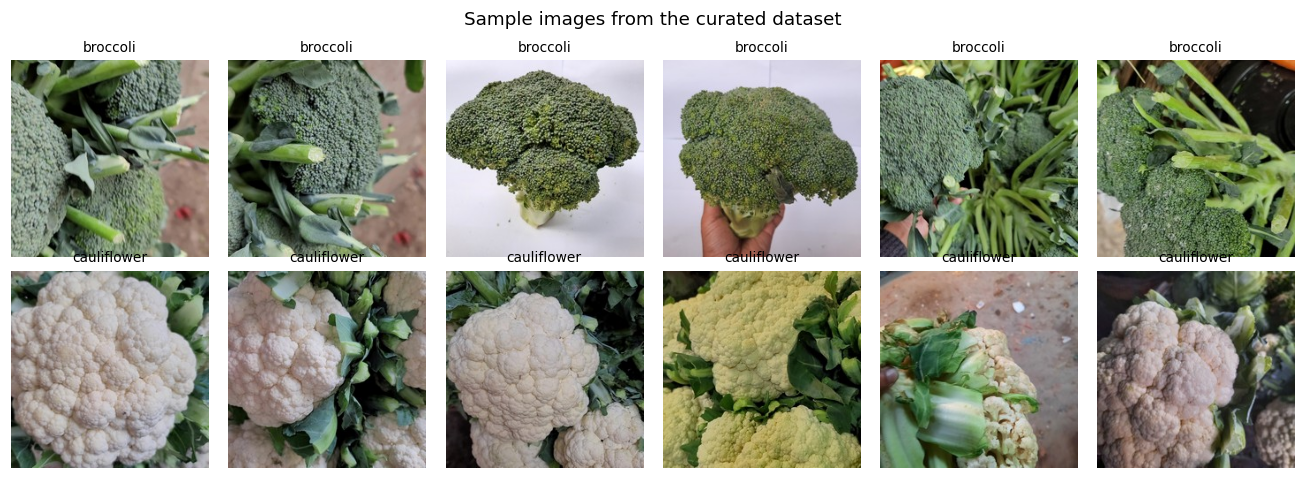

In [11]:
# Sample images from each class
fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for row, cls in enumerate(CLASS_NAMES):
    samples = df[df['class'] == cls].sample(6, random_state=0)
    for ax, path in zip(axes[row], samples['X']):
        ax.imshow(Image.open(path))
        ax.set_title(cls, fontsize=9)
        ax.axis('off')
fig.suptitle('Sample images from the curated dataset')
plt.tight_layout()
plt.show()

<h5><strong> Hanalysis 🍀: </h5></strong>

Most images show a single vegetable in a clear close-up. Broccoli is mainly green, while cauliflower is white. They also have similar shapes and textures, making them a useful pair for testing the models.

<h3><strong>3. Custom PyTorch `Dataset`</strong></h3>


Here, I create a custom PyTorch `Dataset` to prepare the images for inference.

1. **Get the image information**  
   using `data_dict` to get each image's file path and corresponding class label.

2. **Load the image**  
   opening each image using **PIL** and convert it to **RGB** format. This matches the format expected by the pretrained `torchvision` models.

3. **Apply preprocessing**  
   applying the transform passed to the dataset. This allows us to use the appropriate preprocessing for each model.

4. **Return the data**  
   For each image, the dataset returns the processed image and its corresponding label.

In [12]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = Image.open(self.data_dict['X'][idx]).convert('RGB')
        y = self.data_dict['y'][idx]
        if self.transforms:
            x = self.transforms(x)
        y = torch.tensor(y)
        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

In [ ]:
# Quick test with a basic transform
trans = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
])

cd = CustomDataset(data_dict, trans)
print('Dataset size:', len(cd))

for i in range(3):
    x, y = cd[i]
    print(x.shape, '-> label', y.item(), f'({CLASS_NAMES[y]})')

Dataset size: 2000
torch.Size([3, 224, 224]) -> label 0 (broccoli)
torch.Size([3, 224, 224]) -> label 0 (broccoli)
torch.Size([3, 224, 224]) -> label 0 (broccoli)


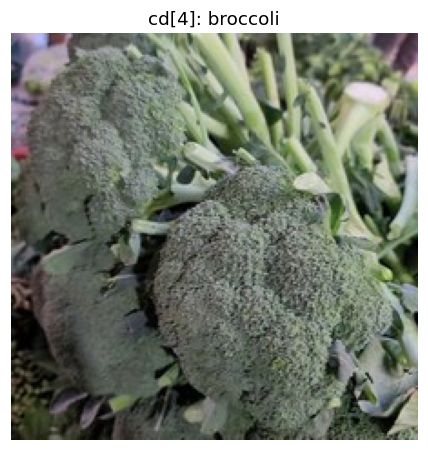

In [14]:
x, y = cd[4]
plt.imshow(x.permute(1, 2, 0))
plt.title(f'cd[4]: {CLASS_NAMES[y]}')
plt.axis('off')
plt.show()

<h3><strong>4. Selecting the Pre-trained Models</strong></h3>

I used five **ImageNet-1K pretrained models** to compare different model architectures, sizes, and design approaches.

- **ResNet-18** — a lightweight residual CNN
- **ResNet-50** — a deeper residual CNN with bottleneck blocks
- **MobileNetV3-Large** — a lightweight CNN designed for mobile devices
- **EfficientNet-B0** — a CNN that balances depth, width, and image resolution
- **ViT-B/16** — a Vision Transformer that processes images as 16×16 patches using self-attention

Each model uses its corresponding pretrained **weights** from `torchvision.models`. The weights provide a `.transforms()` method containing the preprocessing used during training, such as resizing, center cropping, and ImageNet normalization.

In [15]:
MODEL_SPECS = {
    'ResNet-18':         (models.resnet18,           models.ResNet18_Weights.DEFAULT),
    'ResNet-50':         (models.resnet50,           models.ResNet50_Weights.DEFAULT),
    'MobileNetV3-Large': (models.mobilenet_v3_large, models.MobileNet_V3_Large_Weights.DEFAULT),
    'EfficientNet-B0':   (models.efficientnet_b0,    models.EfficientNet_B0_Weights.DEFAULT),
    'ViT-B/16':          (models.vit_b_16,           models.ViT_B_16_Weights.DEFAULT),
}
MODEL_NAMES = list(MODEL_SPECS)
COLOR = dict(zip(MODEL_NAMES, MODEL_COLORS))

<h3><strong>5. DataLoaders</strong></h3> 

Since each model has its own preprocessing requirements, I create a separate `DataLoader` for each model while using the same 2,000 images.

Each `DataLoader`:
- Uses `batch_size=32` to process the images in batches.
- Sets `shuffle=False` so the image order stays consistent, keeping the predictions aligned with their corresponding labels during evaluation.

In [17]:
BATCH_SIZE = 32

loaders = {}
for name, (builder, weights) in MODEL_SPECS.items():
    ds = CustomDataset(data_dict, transforms=weights.transforms())
    loaders[name] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(loaders['ResNet-50']))
print('One batch:', xb.shape, yb.shape)
print('Batches per model:', len(loaders['ResNet-50']))

One batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Batches per model: 63


<h5><strong> Hanalysis 🍀: </h5></strong>

Each batch contains **32 RGB images** with a shape of `[32, 3, 224, 224]`. The images are resized and center-cropped to **224×224**, the input size expected by all five models.

The 2,000 images are processed in **63 batches**.

<h3><strong>6. Model Inference</strong></h3>  

For each model, the inference process follows the same steps:

1. Load the pretrained weights and set the model to `eval()` mode.
2. Process each batch using `torch.no_grad()` to disable gradient computation.
3. Store the model's output scores for all 1,000 ImageNet classes for each image.
4. Measure inference time after a warm-up batch to avoid including one-time startup overhead

In [ ]:
def sync():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()


@torch.no_grad()
def run_inference(model, loader):
    model.eval().to(device)

    # Warm-up batch (not timed)
    xb, _ = next(iter(loader))
    model(xb.to(device))
    sync()

    all_logits, all_labels = [], []
    start = time.perf_counter()
    for xb, yb in loader:
        all_logits.append(model(xb.to(device)).cpu())
        all_labels.append(yb)
    sync()
    elapsed = time.perf_counter() - start

    return torch.cat(all_logits), torch.cat(all_labels), elapsed

In [20]:
results = {}

for name, (builder, weights) in MODEL_SPECS.items():
    model = builder(weights=weights)
    n_params = sum(p.numel() for p in model.parameters())

    logits, labels, elapsed = run_inference(model, loaders[name])
    results[name] = {
        'logits': logits,
        'y_true': labels.numpy(),
        'params_M': n_params / 1e6,
        'ms_per_img': 1000 * elapsed / len(labels),
    }
    print(f'{name:<18} {n_params/1e6:6.1f}M params | {elapsed:6.1f}s total | {1000*elapsed/len(labels):5.2f} ms/image')

    del model

ResNet-18            11.7M params |    6.8s total |  3.42 ms/image


ResNet-50            25.6M params |   17.3s total |  8.66 ms/image


MobileNetV3-Large     5.5M params |    6.9s total |  3.43 ms/image


EfficientNet-B0       5.3M params |   11.3s total |  5.65 ms/image


ViT-B/16             86.6M params |   44.5s total | 22.24 ms/image


<h5><strong> Hanalysis 🍀: </h5></strong>

From the results, I can say that the inference speed varies across the models. **ResNet-18** and **MobileNetV3-Large** are the fastest at around **3.4 ms/image**, while **ViT-B/16** is the slowest at around **22 ms/image**.

<h3><strong>7. Evaluation</strong></h3> 

The models predict **1,000 ImageNet classes**, while our dataset contains only broccoli and cauliflower. I evaluate them in two ways:

**A. Two-Class Evaluation (Main Result)**

I keep only the scores for:
- **Broccoli** — 937
- **Cauliflower** — 938

The higher score determines the prediction. I use **accuracy, precision, recall, F1-score, macro F1, and ROC-AUC** to compare the models. Cauliflower is treated as the positive class.

**B. Strict Top-1 Accuracy**

I also check whether the model's highest prediction across all **1,000 ImageNet classes** matches the true class. This is stricter because the model can predict other classes instead.

In [21]:
rows = []
for name, r in results.items():
    logits, y_true = r['logits'], r['y_true']

    two_logits = logits[:, TARGET_IDX]                     # keep only [broccoli, cauliflower] scores
    two_probs = F.softmax(two_logits, dim=1).numpy()
    y_pred = two_probs.argmax(axis=1)
    p_cauliflower = two_probs[:, 1]

    strict_pred = logits.argmax(dim=1).numpy()             # top-1 over all 1,000 classes
    strict_correct = strict_pred == np.array(TARGET_IDX)[y_true]

    r.update(y_pred=y_pred, p_cauliflower=p_cauliflower, strict_pred=strict_pred)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'ROC-AUC': roc_auc_score(y_true, p_cauliflower),
        'Strict top-1 Acc': strict_correct.mean(),
        'Errors (of 2,000)': int((y_pred != y_true).sum()),
        'Params (M)': r['params_M'],
        'ms / image': r['ms_per_img'],
    })

metrics_df = pd.DataFrame(rows).set_index('Model').sort_values('Macro F1', ascending=False)
metrics_df.style.format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-score': '{:.2%}',
    'Macro F1': '{:.2%}', 'ROC-AUC': '{:.5f}', 'Strict top-1 Acc': '{:.2%}',
    'Params (M)': '{:.1f}', 'ms / image': '{:.2f}',
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'Macro F1', 'ROC-AUC', 'Strict top-1 Acc'],
                 props='font-weight: bold')

,Accuracy,Precision,Recall,F1-score,Macro F1,ROC-AUC,Strict top-1 Acc,"Errors (of 2,000)",Params (M),ms / image
Model,,,,,,,,,,
ResNet-50,99.95%,99.90%,100.00%,99.95%,99.95%,1.00000,98.95%,1,25.6,8.66
MobileNetV3-Large,99.90%,99.80%,100.00%,99.90%,99.90%,0.99998,96.75%,2,5.5,3.43
ViT-B/16,99.80%,99.60%,100.00%,99.80%,99.80%,1.00000,98.90%,4,86.6,22.24
EfficientNet-B0,99.70%,99.40%,100.00%,99.70%,99.70%,0.99999,98.20%,6,5.3,5.65
ResNet-18,99.65%,99.30%,100.00%,99.65%,99.65%,0.99999,95.60%,7,11.7,3.42


In [22]:
# Per-class precision / recall / F1 for each model
for name in MODEL_NAMES:
    r = results[name]
    print(f'===== {name} =====')
    print(classification_report(r['y_true'], r['y_pred'], target_names=CLASS_NAMES, digits=4))

===== ResNet-18 =====
              precision    recall  f1-score   support

    broccoli     1.0000    0.9930    0.9965      1000
 cauliflower     0.9930    1.0000    0.9965      1000

    accuracy                         0.9965      2000
   macro avg     0.9965    0.9965    0.9965      2000
weighted avg     0.9965    0.9965    0.9965      2000

===== ResNet-50 =====
              precision    recall  f1-score   support

    broccoli     1.0000    0.9990    0.9995      1000
 cauliflower     0.9990    1.0000    0.9995      1000

    accuracy                         0.9995      2000
   macro avg     0.9995    0.9995    0.9995      2000
weighted avg     0.9995    0.9995    0.9995      2000

===== MobileNetV3-Large =====
              precision    recall  f1-score   support

    broccoli     1.0000    0.9980    0.9990      1000
 cauliflower     0.9980    1.0000    0.9990      1000

    accuracy                         0.9990      2000
   macro avg     0.9990    0.9990    0.9990      2000


<h5><strong> Hanalysis 🍀: </h5></strong>

Looking at the performance of each model, I observed that:

- All five models scored **over 99.6%** on the two-class metrics without additional training.
- **ResNet-50** performed best, with only **1 error out of 2,000 images**, while **ResNet-18** had the most errors with 7.
- All models achieved **100% recall**, with all errors coming from broccoli being predicted as cauliflower.
- Under strict top-1 accuracy across all **1,000 ImageNet classes**, the scores ranged from **95.6% to 98.95%**.

<h3><strong>8. Visual Comparison</strong></h3> 

<h4><strong> 8.1 Metric comparison </h4></strong> 

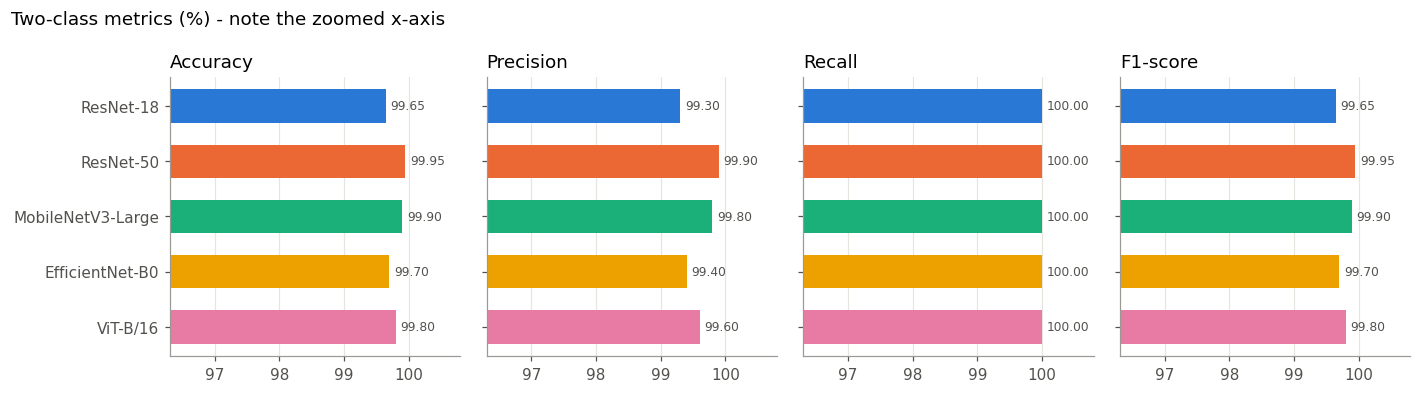

In [ ]:
two_class_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score']
lo = (metrics_df[two_class_cols].values.min() * 100) - 3

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
for ax, col in zip(axes, two_class_cols):
    vals = metrics_df.loc[MODEL_NAMES, col] * 100
    bars = ax.barh(MODEL_NAMES, vals, color=[COLOR[m] for m in MODEL_NAMES], height=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8, color='#52514e')
    ax.set_xlim(max(lo, 0), 100.8)
    ax.set_title(col, loc='left')
    ax.grid(axis='y', visible=False)
axes[0].invert_yaxis()
fig.suptitle('Two-class metrics (%) - note the zoomed x-axis', x=0.01, ha='left')
plt.tight_layout()
plt.show()

<h5><strong> Hanalysis 🍀: </h5></strong>

The performance differences are very small, with only **1–7 errors out of 2,000 images**. **ResNet-50** and **MobileNetV3-Large** stand out as the top two performers, while the differences among the other three models are small enough that they could change with a different set of images.

<h4><strong> 8.2 Confusion matrices </h4></strong> 

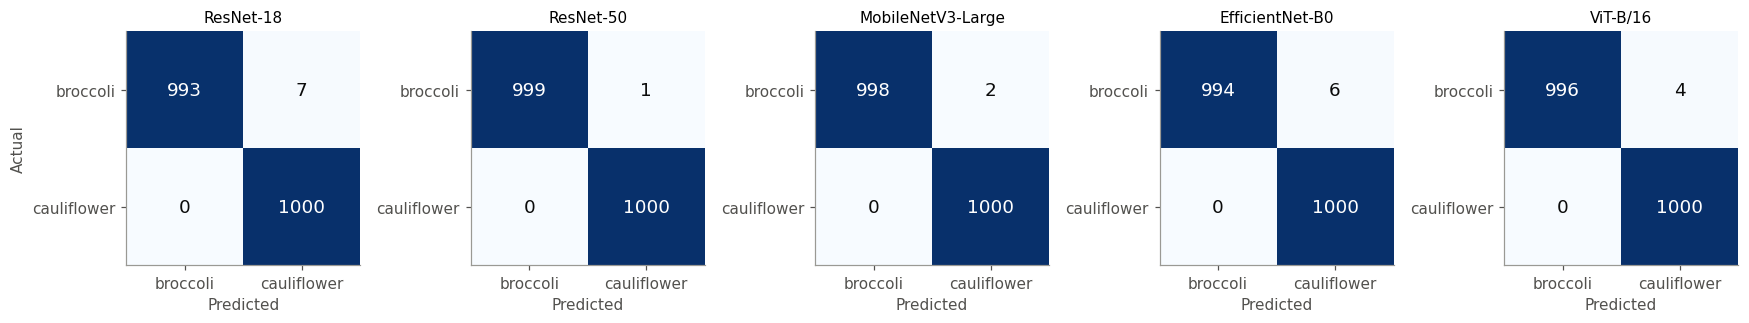

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, name in zip(axes, MODEL_NAMES):
    r = results[name]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.sum(axis=1).max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > cm.max() / 2 else '#0b0b0b')
    ax.set_xticks([0, 1], CLASS_NAMES)
    ax.set_yticks([0, 1], CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.grid(False)
    ax.set_title(name, fontsize=10)
axes[0].set_ylabel('Actual')
plt.tight_layout()
plt.show()

<h5><strong> Hanalysis 🍀: </h5></strong>

All five models correctly classified the **1,000 cauliflower images**. The only errors were **broccoli images predicted as cauliflower**. This may be because cauliflower's white appearance is distinctive, while broccoli with lighter stems or faded color can appear more similar to cauliflower.

<h4><strong> 8.3 Performance vs. model size and speed </h4></strong> 

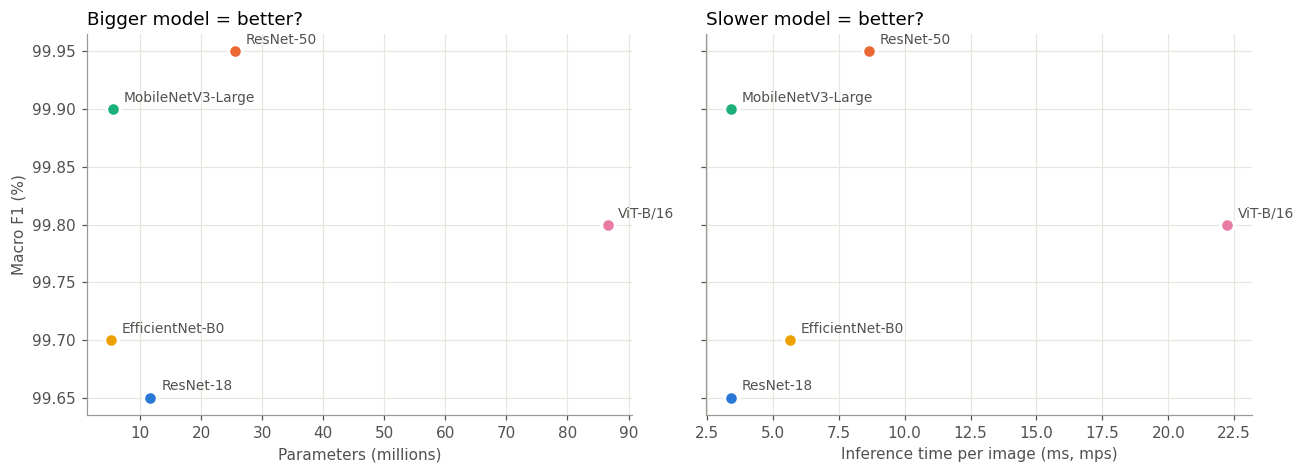

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, col, xlabel in [(axes[0], 'Params (M)', 'Parameters (millions)'),
                        (axes[1], 'ms / image', f'Inference time per image (ms, {device.type})')]:
    for name in MODEL_NAMES:
        xv, yv = metrics_df.loc[name, col], metrics_df.loc[name, 'Macro F1'] * 100
        ax.scatter(xv, yv, s=80, color=COLOR[name], edgecolor='white', linewidth=2, zorder=3)
        ax.annotate(name, (xv, yv), textcoords='offset points', xytext=(7, 5), fontsize=9, color='#52514e')
    ax.set_xlabel(xlabel)
axes[0].set_ylabel('Macro F1 (%)')
axes[0].set_title('Bigger model = better?', loc='left')
axes[1].set_title('Slower model = better?', loc='left')
plt.tight_layout()
plt.show()

<h5><strong> Hanalysis 🍀: </h5></strong>

When comparing **model size, inference speed, and performance**, the results show that **more parameters and slower inference do not necessarily lead to better accuracy**. Although **ViT-B/16** has the largest model size at **86.6M parameters** and is the slowest, it ranks only **3rd**. On the other hand, **MobileNetV3-Large** achieves **2nd place** while using far fewer parameters and running much faster. Hence, **ResNet-50 offers the strongest balance of accuracy, size, and inference speed** among the five models.

<h4><strong> 8.5 What do the models predict out of all 1,000 classes? </h4></strong>  

In [28]:
rows = []
for name in MODEL_NAMES:
    r = results[name]
    for label, cls in enumerate(CLASS_NAMES):
        preds = pd.Series(r['strict_pred'][r['y_true'] == label]).map(lambda i: imagenet_categories[i])
        top = preds.value_counts(normalize=True).head(4)
        rows.append({'Model': name, 'True class': cls,
                     'Most common top-1 predictions': ', '.join(f'{k} ({v:.0%})' for k, v in top.items())})
pd.set_option('display.max_colwidth', None)
pd.DataFrame(rows).set_index(['Model', 'True class'])

Most common top-1 predictions
Model             True class                                                                                  
ResNet-18         broccoli                    broccoli (97%), zucchini (1%), green snake (0%), vine snake (0%)
                  cauliflower  cauliflower (94%), custard apple (3%), head cabbage (1%), hen-of-the-woods (0%)
ResNet-50         broccoli                         broccoli (99%), artichoke (0%), zucchini (0%), cardoon (0%)
                  cauliflower               cauliflower (99%), head cabbage (0%), custard apple (0%), ear (0%)
MobileNetV3-Large broccoli                                  broccoli (99%), zucchini (0%), knot (0%), pot (0%)
                  cauliflower           cauliflower (94%), hen-of-the-woods (2%), custard apple (1%), ear (1%)
EfficientNet-B0   broccoli                         broccoli (98%), zucchini (1%), cauliflower (0%), koala (0%)
                  cauliflower               cauliflower (98%), grocery store (1%), artichoke (0%), banana (0%)
ViT-B/16          broccoli                  broccoli (99%), cauliflower (0%), head cabbage (0%), cucumber (0%)
                  cauliflower                   cauliflower (99%), custard apple (1%), cucumber (0%), ear (0%)

<h5><strong> Hanalysis 🍀: </h5></strong>

I also tried predicting across all **1,000 ImageNet classes**. The errors reveal that the models can recognize the general appearance of the vegetables but may struggle to distinguish them from visually similar classes. Broccoli is sometimes confused with *zucchini*, while cauliflower is confused with *custard apple*, *head cabbage*, and *hen-of-the-woods* due to shared color or texture. **ResNet-50** and **ViT-B/16** are less affected by these distractor classes, suggesting stronger discrimination among similar visual features, while **ResNet-18** and **MobileNetV3-Large** are more prone to these confusions.

<h4><strong> 8.6 Misclassified examples </h4></strong> 

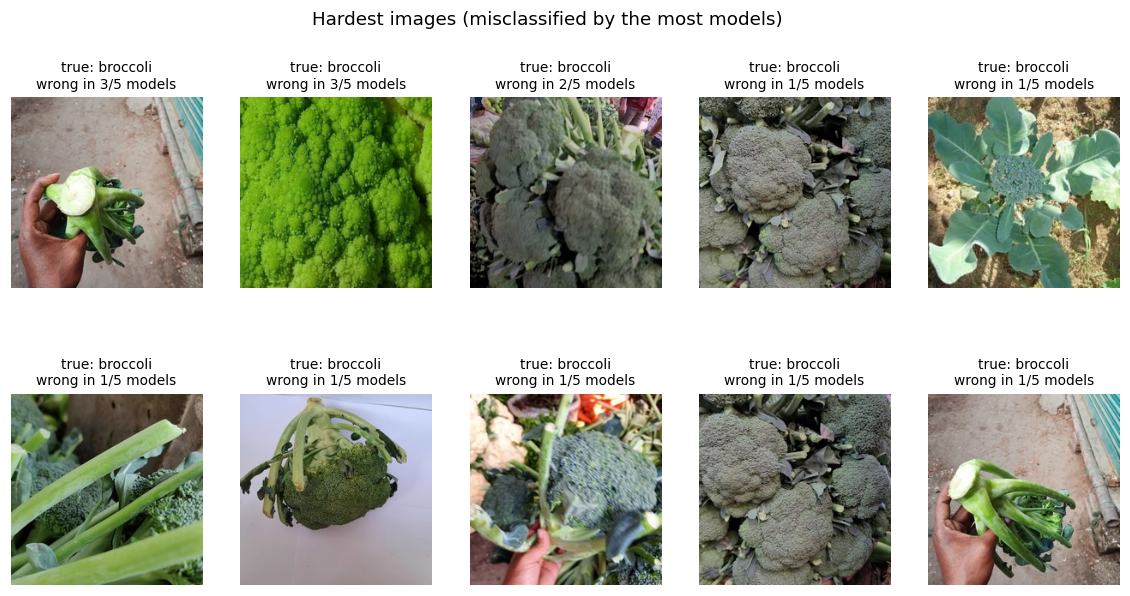

In [ ]:
y_true = results[MODEL_NAMES[0]]['y_true']
wrong_count = sum((results[m]['y_pred'] != y_true).astype(int) for m in MODEL_NAMES)
hardest = np.argsort(-wrong_count, kind='stable')[:10]
hardest = hardest[wrong_count[hardest] > 0]

if len(hardest) == 0:
    print('No image was misclassified by any model.')
else:
    fig, axes = plt.subplots(2, 5, figsize=(13, 6.2), gridspec_kw={'hspace': 0.3})
    for ax in axes.flat:
        ax.axis('off')
    for ax, idx in zip(axes.flat, hardest):
        ax.imshow(Image.open(data_dict['X'][idx]))
        ax.set_title(f'true: {CLASS_NAMES[y_true[idx]]}\nwrong in {wrong_count[idx]}/5 models', fontsize=9)
    fig.suptitle('Hardest images (misclassified by the most models)')
    plt.show()

<h5><strong> Hanalysis 🍀: </h5></strong>

The hardest cases are all **broccoli images**, especially those with unusual visual characteristics. These include pale or white stems, dim lighting, broccoli plants photographed in the field, and romanesco, which closely resembles cauliflower.

<h3><strong>9. Analysis & Conclusion</strong></h3> 

<h4><strong> Key Findings </h4></strong>

All five pretrained models classify broccoli and cauliflower very well, reaching **99.65–99.95% accuracy** using inference alone. This strong performance is expected because both classes are part of ImageNet and most images are clear close-ups.

The differences between the models can be explained by several factors:

- **ResNet-50 performed best**, likely benefiting from its deeper residual architecture and stronger V2 training recipe.
- **ViT-B/16** is much larger than MobileNetV3-Large but performed worse, showing that a larger model does not always provide better results when the task is already simple.
- **MobileNetV3-Large** provides the best efficiency, ranking 2nd while using far fewer parameters and running much faster.
- **Correct preprocessing matters.** Each model's required preprocessing was used, and images were loaded as RGB to match the models' training format.
- Most errors came from **ambiguous images**, such as pale broccoli and romanesco, which are visually similar to cauliflower.

<h4><strong> Overall Takeaway </h4></strong>

**ResNet-50** gives the best overall performance, while **MobileNetV3-Large** offers the best balance of performance and efficiency. The results suggest that for classes already represented in pretraining, **appropriate pretrained weights and preprocessing can matter more than simply using a larger model**.